In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
Path("outputs").mkdir(exist_ok=True)

# Charger les données brutes (CORRIGÉ)
df = pd.read_csv("METABRIC_RNA_Mutation.csv", low_memory=False)  

print("="*70)
print("METABRIC - Data Understanding (Avant Nettoyage)")
print("="*70)
print(f"\nShape : {df.shape}")
print(f"Patients : {df. shape[0]}")
print(f"Variables : {df.shape[1]}")
print(f"Mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Afficher les colonnes problématiques identifiées
problem_cols = [678, 688, 690, 692]
print(f"\n⚠️ Colonnes avec types mixtes détectées :  {problem_cols}")
print("Noms des colonnes problématiques :")
for idx in problem_cols:
    if idx < len(df.columns):
        col_name = df.columns[idx]
        print(f"  - Colonne {idx} : {col_name}")
        print(f"    Types présents : {df[col_name].apply(type).value_counts().to_dict()}")

METABRIC - Data Understanding (Avant Nettoyage)

Shape : (1904, 693)
Patients : 1904
Variables : 693
Mémoire : 24.9 MB

⚠️ Colonnes avec types mixtes détectées :  [678, 688, 690, 692]
Noms des colonnes problématiques :
  - Colonne 678 : rasgef1b_mut
    Types présents : {<class 'str'>: 1904}
  - Colonne 688 : hras_mut
    Types présents : {<class 'str'>: 1904}
  - Colonne 690 : smarcb1_mut
    Types présents : {<class 'str'>: 1904}
  - Colonne 692 : siah1_mut
    Types présents : {<class 'str'>: 1904}


In [5]:
# Afficher les premières lignes
print("\n Aperçu des données :")
print(df.head())

# Types de données
print("\n Types de variables :")
print(df.dtypes. value_counts())

# Statistiques de base
print("\n Statistiques descriptives :")
print(df.describe().T)


 Aperçu des données :
   patient_id  age_at_diagnosis type_of_breast_surgery    cancer_type  \
0           0             75.65             MASTECTOMY  Breast Cancer   
1           2             43.19      BREAST CONSERVING  Breast Cancer   
2           5             48.87             MASTECTOMY  Breast Cancer   
3           6             47.68             MASTECTOMY  Breast Cancer   
4           8             76.97             MASTECTOMY  Breast Cancer   

                        cancer_type_detailed cellularity  chemotherapy  \
0           Breast Invasive Ductal Carcinoma         NaN             0   
1           Breast Invasive Ductal Carcinoma        High             0   
2           Breast Invasive Ductal Carcinoma        High             1   
3  Breast Mixed Ductal and Lobular Carcinoma    Moderate             1   
4  Breast Mixed Ductal and Lobular Carcinoma        High             1   

  pam50_+_claudin-low_subtype  cohort er_status_measured_by_ihc  ... mtap_mut  \
0           


 Valeurs manquantes :
                      Variable  Manquant  Pourcentage
                   tumor_stage       501         26.3
     3-gene_classifier_subtype       204         10.7
      primary_tumor_laterality       106          5.6
     neoplasm_histologic_grade        72          3.8
                   cellularity        54          2.8
                mutation_count        45          2.4
     er_status_measured_by_ihc        30          1.6
        type_of_breast_surgery        22          1.2
                    tumor_size        20          1.1
          cancer_type_detailed        15          0.8
tumor_other_histologic_subtype        15          0.8
                 oncotree_code        15          0.8
             death_from_cancer         1          0.1


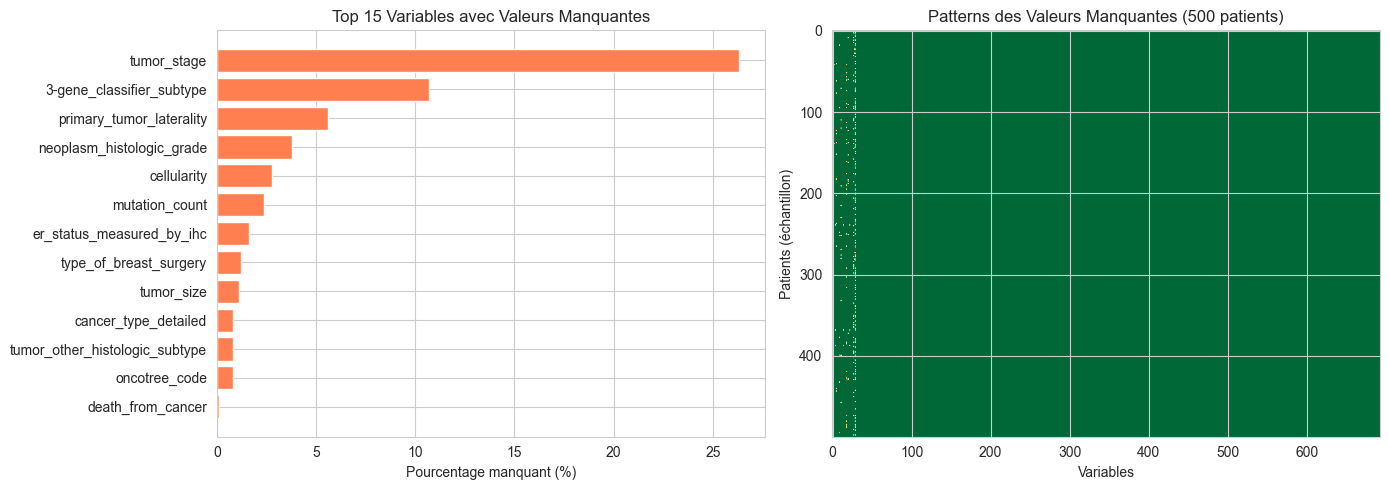


 Insight : 13/693 variables ont des valeurs manquantes


In [7]:
# Compter les valeurs manquantes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Variable': missing.index,
    'Manquant': missing.values,
    'Pourcentage': missing_pct. values
}).query('Manquant > 0').sort_values('Manquant', ascending=False)

print("\n Valeurs manquantes :")
print(missing_df. to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Top variables avec missing
if len(missing_df) > 0:
    top_missing = missing_df.head(15)
    axes[0].barh(top_missing['Variable'], top_missing['Pourcentage'], color='coral')
    axes[0].set_xlabel('Pourcentage manquant (%)')
    axes[0].set_title('Top 15 Variables avec Valeurs Manquantes')
    axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, 'Aucune valeur manquante', ha='center', va='center')

# Graphique 2 : Heatmap des missing (échantillon)
sample_size = min(500, len(df))
axes[1].imshow(df.sample(sample_size).isnull(), cmap='RdYlGn_r', aspect='auto')
axes[1].set_title(f'Patterns des Valeurs Manquantes ({sample_size} patients)')
axes[1].set_xlabel('Variables')
axes[1].set_ylabel('Patients (échantillon)')

plt.tight_layout()
plt.savefig('outputs/1_missing_values.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n Insight : {len(missing_df)}/{len(df. columns)} variables ont des valeurs manquantes")

In [8]:
# Chercher la colonne cible (adaptez le nom)
target_candidates = ['diagnosis', 'target', 'class', 'label', 'outcome']
target_col = None

for col in target_candidates:
    if col in df.columns:
        target_col = col
        break

if target_col:
    print(f"\n Variable cible détectée : {target_col}")
    
    # Compter les classes
    target_counts = df[target_col].value_counts()
    target_pct = (target_counts / len(df) * 100).round(1)
    
    print(f"\nDistribution de {target_col} :")
    for idx, val in target_counts.items():
        print(f"  {idx} : {val} ({target_pct[idx]}%)")
    
    # Visualisation
    fig, axes = plt. subplots(1, 2, figsize=(12, 4))
    
    # Barplot
    axes[0].bar(range(len(target_counts)), target_counts.values, 
                color=['lightgreen', 'salmon'][:  len(target_counts)])
    axes[0].set_xticks(range(len(target_counts)))
    axes[0].set_xticklabels(target_counts.index)
    axes[0].set_ylabel('Nombre de patients')
    axes[0].set_title(f'Distribution de la cible ({target_col})')
    
    # Ajouter pourcentages
    for i, v in enumerate(target_counts.values):
        axes[0].text(i, v, f'{v}\n({target_pct. iloc[i]}%)', 
                    ha='center', va='bottom', fontweight='bold')
    
    # Pie chart
    axes[1].pie(target_counts.values, labels=target_counts.index, 
                autopct='%1.1f%%', startangle=90, 
                colors=['lightgreen', 'salmon'][:len(target_counts)])
    axes[1].set_title('Proportion des classes')
    
    plt.tight_layout()
    plt.savefig('outputs/2_target_distribution.png', dpi=200, bbox_inches='tight')
    plt.show()
    
    # Détecter déséquilibre
    min_class_pct = target_pct.min()
    if min_class_pct < 30:
        print(f"\n DÉSÉQUILIBRE DÉTECTÉ : classe minoritaire = {min_class_pct}%")
        print("   → Considérer :  SMOTE, class_weight, stratified split")
    else:
        print("\n✓ Classes relativement équilibrées")
else:
    print("\n Aucune colonne cible détectée.  Spécifiez manuellement.")


 Aucune colonne cible détectée.  Spécifiez manuellement.



 503 variables numériques détectées


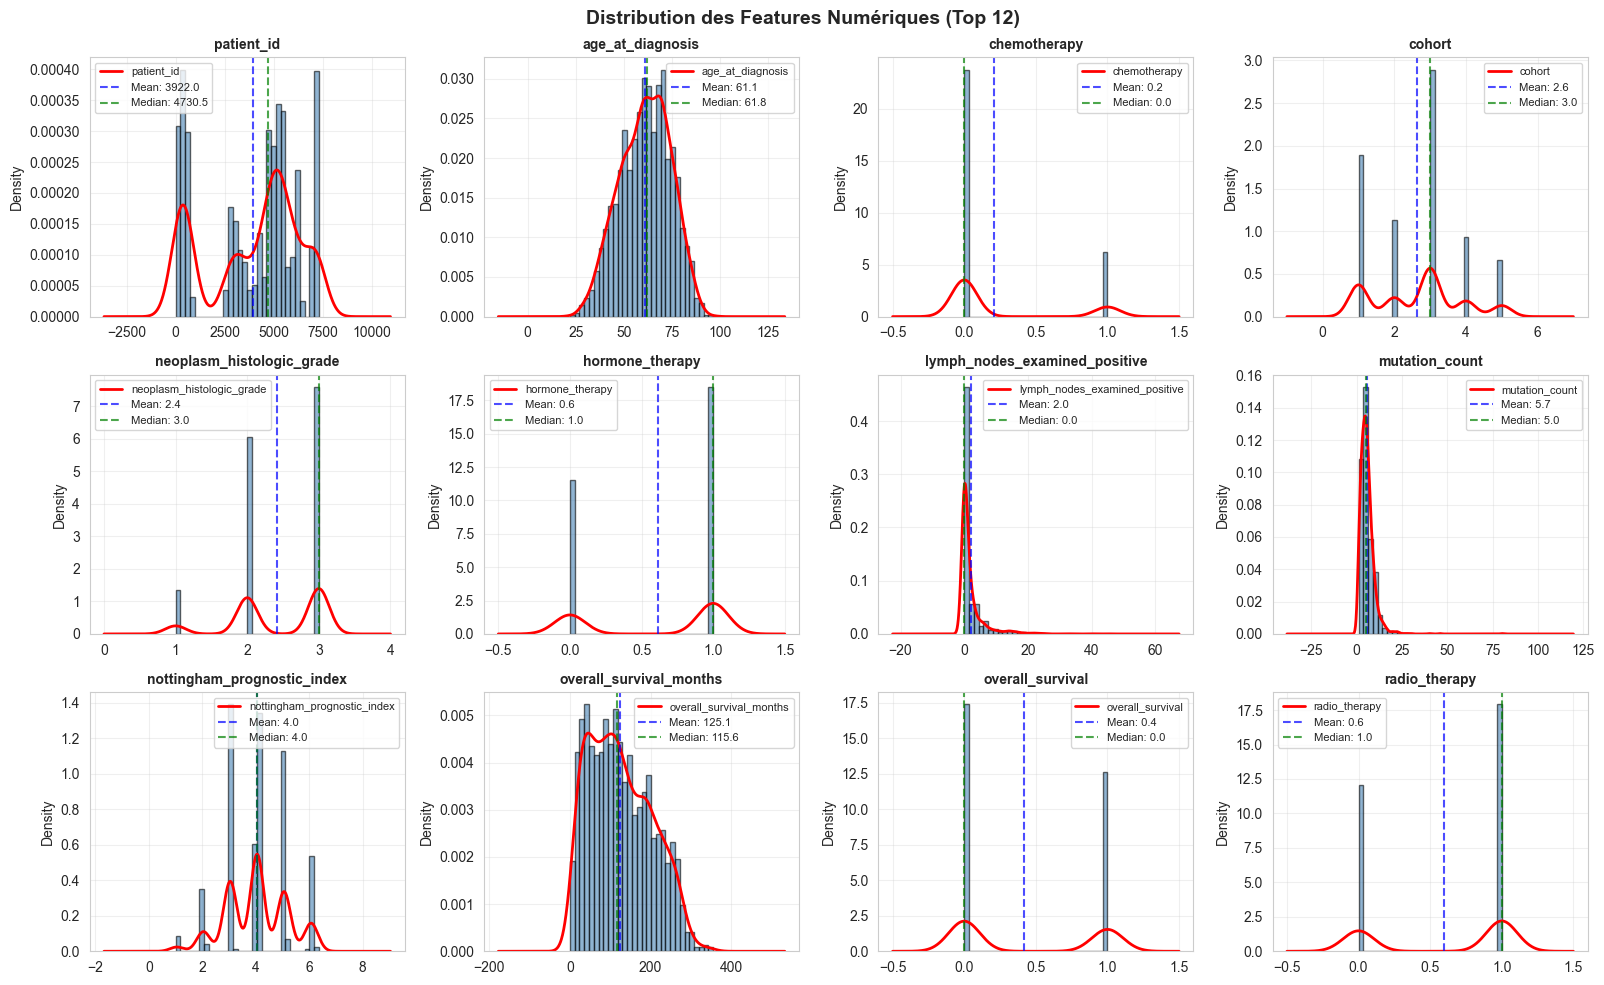


 Observez :  asymétrie, outliers, besoin de transformation


In [10]:
# Sélectionner variables numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n {len(numeric_cols)} variables numériques détectées")

# Visualiser les 12 premières
n_features = min(12, len(numeric_cols))
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[: n_features]):
    data = df[col].dropna()
    
    # Histogramme + KDE
    axes[i].hist(data, bins=30, alpha=0.6, color='steelblue', edgecolor='black', density=True)
    data. plot(kind='kde', ax=axes[i], color='red', linewidth=2)
    
    # Stats
    mean_val = data.mean()
    median_val = data.median()
    axes[i].axvline(mean_val, color='blue', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='green', linestyle='--', alpha=0.7, label=f'Median: {median_val:.1f}')
    
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

# Masquer axes vides
for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution des Features Numériques (Top 12)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/3_numeric_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n Observez :  asymétrie, outliers, besoin de transformation")

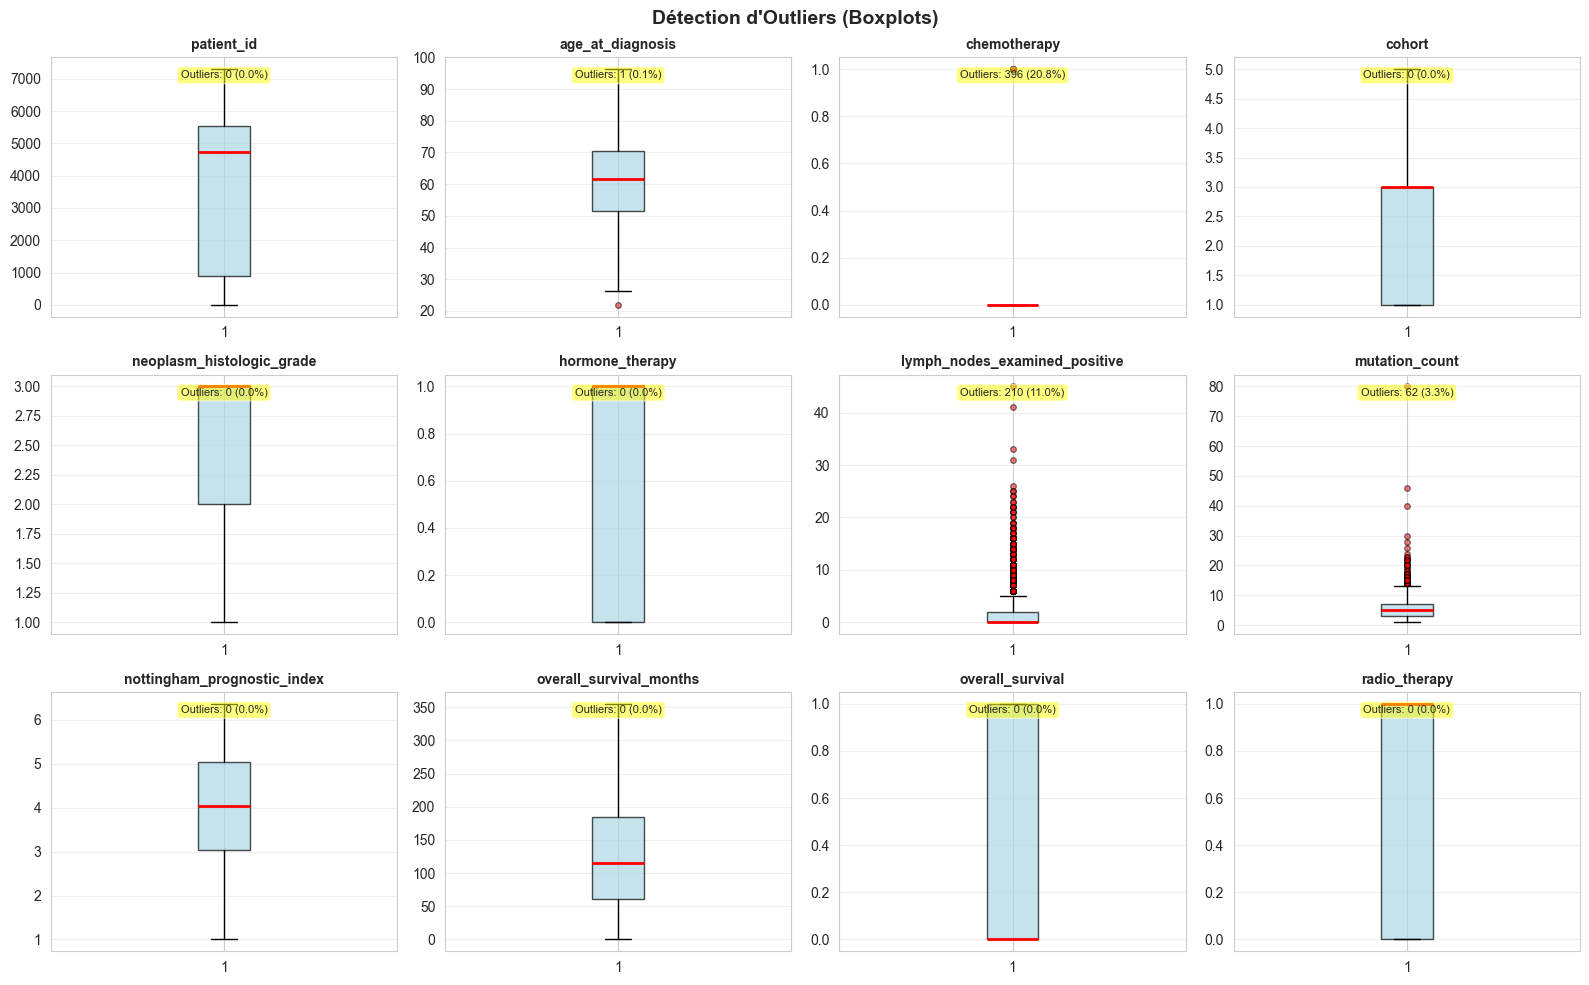


 Outliers détectés → Décider :  garder, transformer, ou supprimer


In [11]:
# Boxplots des variables numériques
n_features = min(12, len(numeric_cols))
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:n_features]):
    data = df[col].dropna()
    
    bp = axes[i].boxplot(data, vert=True, patch_artist=True,
                         boxprops=dict(facecolor='lightblue', alpha=0.7),
                         medianprops=dict(color='red', linewidth=2),
                         flierprops=dict(marker='o', markerfacecolor='red', markersize=4, alpha=0.5))
    
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].grid(axis='y', alpha=0.3)
    
    # Compter outliers
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5*IQR) | (data > Q3 + 1.5*IQR)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(data) * 100)
    
    axes[i]. text(0.5, 0.95, f'Outliers: {n_outliers} ({pct_outliers:.1f}%)',
                transform=axes[i].transAxes, ha='center', va='top',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5), fontsize=8)

for j in range(n_features, len(axes)):
    axes[j].axis('off')

plt.suptitle('Détection d\'Outliers (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/4_outliers_boxplots.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n Outliers détectés → Décider :  garder, transformer, ou supprimer")


 190 variables catégorielles détectées

Cardinalité (nombre de catégories uniques) :
  type_of_breast_surgery : 2 catégories
  cancer_type : 2 catégories
  cancer_type_detailed : 6 catégories
  cellularity : 3 catégories
  pam50_+_claudin-low_subtype : 7 catégories
  er_status_measured_by_ihc : 2 catégories
  er_status : 2 catégories
  her2_status_measured_by_snp6 : 4 catégories
  her2_status : 2 catégories
  tumor_other_histologic_subtype : 8 catégories
  inferred_menopausal_state : 2 catégories
  integrative_cluster : 11 catégories
  primary_tumor_laterality : 2 catégories
  oncotree_code : 6 catégories
  pr_status : 2 catégories


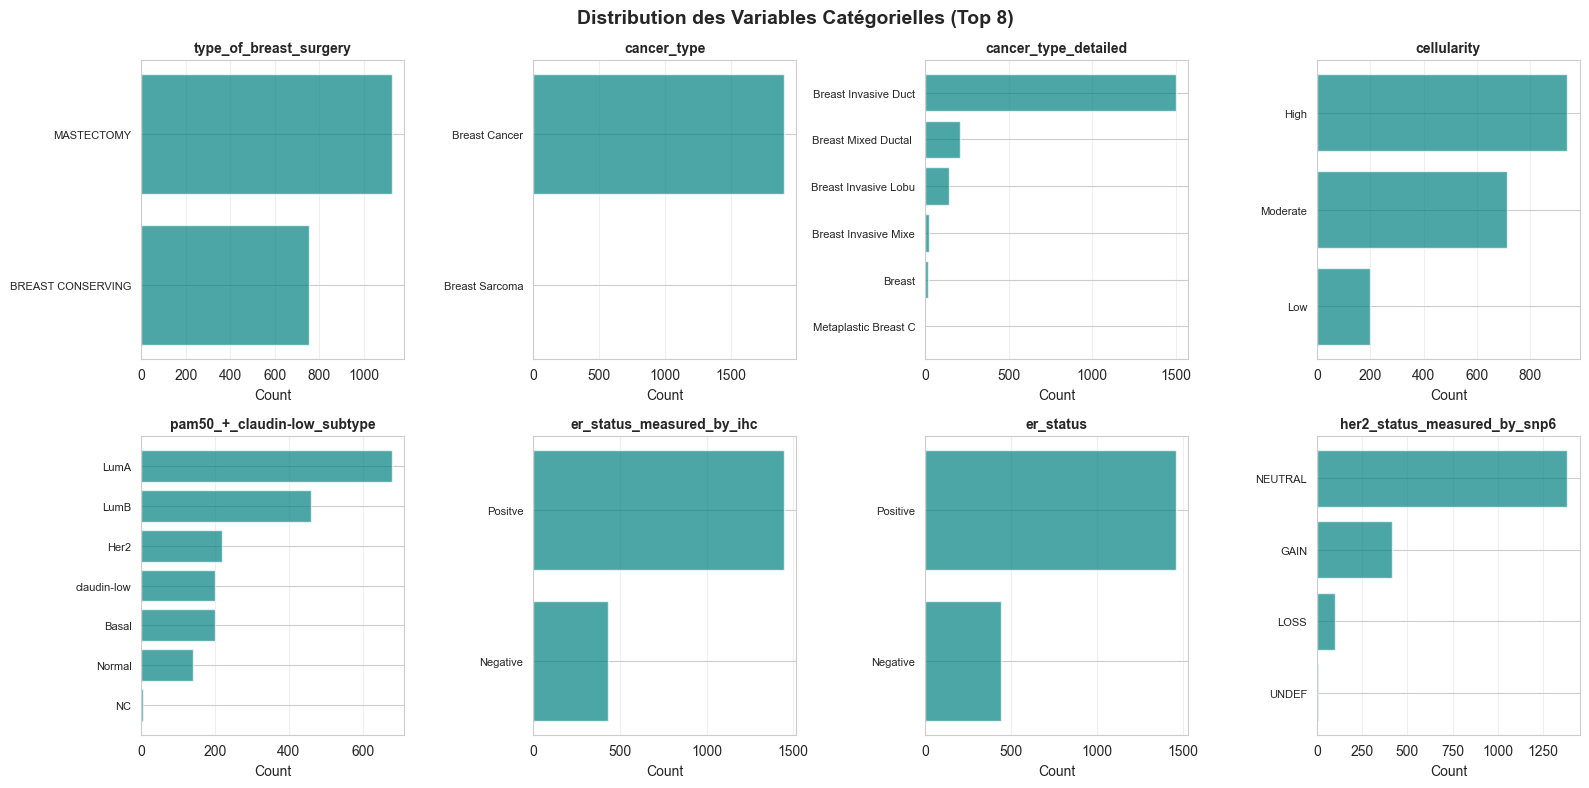


 HAUTE CARDINALITÉ détectée (47 variables > 50 catégories)
   → Considérer : Target Encoding, Embedding, ou regroupement


In [13]:
# Sélectionner variables catégorielles
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\n {len(categorical_cols)} variables catégorielles détectées")

if len(categorical_cols) > 0:
    # Afficher cardinalité
    print("\nCardinalité (nombre de catégories uniques) :")
    for col in categorical_cols[: 15]:  # Max 15
        n_unique = df[col].nunique()
        print(f"  {col} : {n_unique} catégories")
    
    # Visualiser les 8 premières
    n_cat = min(8, len(categorical_cols))
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    for i, col in enumerate(categorical_cols[: n_cat]):
        counts = df[col].value_counts().head(10)  # Top 10 catégories
        axes[i]. barh(range(len(counts)), counts.values, color='teal', alpha=0.7)
        axes[i].set_yticks(range(len(counts)))
        axes[i].set_yticklabels([str(x)[:20] for x in counts.index], fontsize=8)  # Tronquer long noms
        axes[i].set_xlabel('Count')
        axes[i].set_title(col, fontsize=10, fontweight='bold')
        axes[i].invert_yaxis()
        axes[i].grid(axis='x', alpha=0.3)
    
    for j in range(n_cat, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle('Distribution des Variables Catégorielles (Top 8)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/7_categorical_distributions.png', dpi=200, bbox_inches='tight')
    plt.show()
    
    # Détecter cardinalité élevée
    high_card = [col for col in categorical_cols if df[col].nunique() > 50]
    if high_card:
        print(f"\n HAUTE CARDINALITÉ détectée ({len(high_card)} variables > 50 catégories)")
        print("   → Considérer : Target Encoding, Embedding, ou regroupement")
else:
    print("\n✓ Aucune variable catégorielle détectée")